In [1]:
library(dplyr)
library(ggplot2)
library(data.table)

source("/mnt/lareaulab/reliscu/code/ggplot_theme.R")

source("/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/code/top_corr_module_fxns.R")

theme_set(default_theme())
options(repr.matrix.max.cols=Inf) 


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last




In [2]:
setwd("/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/MOp")

Goal: verify enriched modules actually represent a given cell type by plotting cell type abundance vs. the module eigengene

In [3]:
# These should match the settings used to get enrichment results in previous step

mod_def <- "PosBC"
unique <- FALSE 

In [4]:
pairwise_res_list <- readRDS("data/DE_genes/yao_2021_MOp_STAR_donor_cell_type_pseudobulk_pairwise_DE_genes_dream.RDS")
pairwise_ctype_genes <- prep_DE_genes(pairwise_res_list, pairwise=TRUE, unique=unique)

## Round 1 (SD = 25, mergeParam = 0.85)

In [7]:
network_dir <- "yao_2021_MOp_STAR_20pcntCells_25SD_200samples_pseudobulk_mergeParam0.85_Modules"
pseudobulk_legend <- read.csv("data/SyntheticDatasets/SyntheticDataset1_20pcntCells_25SD_200samples_legend_11-19-35.csv")
top_qval_mods_df <- read.csv("data/enrichments/yao_2021_MOp_pairwise_DE_genes_dream_uniqueFALSE_20pcntCells_25SD_200samples_pseudobulk_mergeParam0.85_PosBC_top_Qval_modules.csv")

pseudobulk_legend$Cell.type <- sapply(pseudobulk_legend$Cell.type, function(x) gsub(" ", "_", x))
pseudobulk_legend$Cell.type <- sapply(pseudobulk_legend$Cell.type, function(x) gsub("/", "_", x, fixed=TRUE))

In [8]:
networks <- list.dirs(file.path(getwd(), network_dir), full.names=TRUE, recursive=FALSE)
networks <- networks[lengths(lapply(networks, list.files)) > 0]


In [ ]:

enrichments_list <- lapply(seq_along(networks), function(i) {
    kME_path <- list.files(networks[i])[grep("kME", list.files(networks[i]))]
    kME <- fread(file.path(networks[i], kME_path), data.table=FALSE)
    mod_assignment_col <- grep(mod_def, colnames(kME))
    mod_genes <- tapply(kME$Gene, kME[,mod_assignment_col], list)
    
    if (length(mod_genes) > 0) {
        all_genes <- kME$Gene

        # For each module: calculate enrichment for DE genes from each cell type
        mod_enrichments_list <- lapply(mod_genes, function(mod) {
            lapply(unlist(lapply(ctype_gene_list, function(set) {
                fisher_test(set, mod, all=all_genes)
            })), c)
        })
        
        # Save the network the module came from
        network_id <- sapply(strsplit(networks[i], "/"), function(x) x[length(x)])
        mod_enrichments_df <- reshape2::melt(mod_enrichments_list)
        colnames(mod_enrichments_df) <- c("Pval", "Cell_type", "Module")
        
        # Save path to module eigengenes table for downstream analyses
        ME_path <- list.files(networks[i])[grep("eigengene", list.files(networks[i]))]
        
        data.frame(
            Network=network_id,
            kME_path=file.path(networks[i], kME_path),
            ME_path=file.path(networks[i], ME_path),
            mod_enrichments_df
        )
    }
})
enrichments_df <- do.call(rbind, enrichments_list)
enrichments_df$Qval <- qvalue(enrichments_df$Pval)$qvalue

In [10]:
ctype_genes_list <- pairwise_ctype_genes

top_corr_mods_df <- get_top_corr_mods(network_dir, pseudobulk_legend, top_qval_mods_df, ctype_genes_list, mod_def)
top_corr_mods_df %>% arrange(Old_cor)

,Cell_type,Pseudobulk_SD,Cor,Old_cor,Pval,Old_pval,Module_genes,Old_module_genes,DE_genes,Module,Old_module,Network,Old_network,ME_path,Old_ME_path,kME_path,Old_kME_path
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
plum1,pvalb_GABAergic_cortical_interneuron,23.79,0.9153963,0.5088048,8.499013e-96,1.022042e-130,"Pvalb, Nog, Tac1, Nek7, Gm13629, Kcnc1, Syt2, Kcnc2, 6330411D24Rik, St3gal6, Eya4, Ank1, Cox6a2, Gpr83, Pacsin2","Uqcrh, Atp5mc3, Ndufa3, Ndufc1, Atp5pf, Atp5mf, Cox5a, Ndufb8, Cox5b, Cox7b, Cox7c, Gm26631, Ndufa6, Ndufv2, Uqcr10","Sncb, Slc38a1, Hspbp1, Fchsd1, Glrx5, Rell2, Nt5m, Sars1, Bend6, Got2, Slbp, Ndufaf5, Ppp1cc, Asns, Clec2l",plum1,black,Bicor-None_signum0.668_minSize4_merge_ME_0.85_20619,Bicor-None_signum0.668_minSize12_merge_ME_0.85_20619,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/MOp/yao_2021_MOp_STAR_20pcntCells_25SD_200samples_pseudobulk_mergeParam0.85_Modules/Bicor-None_signum0.668_minSize4_merge_ME_0.85_20619/Module_eigengenes_12-56-30.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/MOp/yao_2021_MOp_STAR_20pcntCells_25SD_200samples_pseudobulk_mergeParam0.85_Modules/Bicor-None_signum0.668_minSize12_merge_ME_0.85_20619/Module_eigengenes_01-02-12.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/MOp/yao_2021_MOp_STAR_20pcntCells_25SD_200samples_pseudobulk_mergeParam0.85_Modules/Bicor-None_signum0.668_minSize4_merge_ME_0.85_20619/kME_table_12-56-30.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/MOp/yao_2021_MOp_STAR_20pcntCells_25SD_200samples_pseudobulk_mergeParam0.85_Modules/Bicor-None_signum0.668_minSize12_merge_ME_0.85_20619/kME_table_01-02-12.csv
plum11,VIP_GABAergic_cortical_interneuron,25.23,0.9184509,0.7716659,1.638108e-70,4.683666e-99,"Igsf3, Tiam1, Grpr, Pthlh, Gpd1, Gm42538, Limch1, Calb2, Sall1, Penk, Crlf1, Slc18a3, Sostdc1, Ostf1, Srrm4","Vip, Igf1, Ap1s2, Gm17750, Prox1, Prox1os, Crh, Tac2, Asic4, Adra1b, Cxcl14, Vstm2l, Shisa8, Wnt5a, Gm37264","C1qtnf4, Arfgef3, Uchl4, Vstm2l, Ugcg, Castor2, Uchl3, Csmd3, Plvap, Cit, Sobp, Srrm4, Tiam1, Asic1, A330076H08Rik",plum1,tan,Bicor-None_signum0.114_minSize10_merge_ME_0.85_20619,Bicor-None_signum0.668_minSize6_merge_ME_0.85_20619,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/MOp/yao_2021_MOp_STAR_20pcntCells_25SD_200samples_pseudobulk_mergeParam0.85_Modules/Bicor-None_signum0.114_minSize10_merge_ME_0.85_20619/Module_eigengenes_03-29-52.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/MOp/yao_2021_MOp_STAR_20pcntCells_25SD_200samples_pseudobulk_mergeParam0.85_Modules/Bicor-None_signum0.668_minSize6_merge_ME_0.85_20619/Module_eigengenes_12-59-10.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/MOp/yao_2021_MOp_STAR_20pcntCells_25SD_200samples_pseudobulk_mergeParam0.85_Modules/Bicor-None_signum0.114_minSize10_merge_ME_0.85_20619/kME_table_03-29-52.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/MOp/yao_2021_MOp_STAR_20pcntCells_25SD_200samples_pseudobulk_mergeParam0.85_Modules/Bicor-None_signum0.668_minSize6_merge_ME_0.85_20619/kME_table_12-59-10.csv
plum12,L4_5_intratelencephalic_projecting_glutamatergic_neuron_of_the_primary_motor_cortex,28.50,0.8495230,0.8495230,1.113881e-52,2.561485e-71,"Krt12, A830036E02Rik, Dnajc21, Hspb3, Sac3d1, Grm2, Nrxn1, Dapk2, Adcyap1, Crhr1, Gtdc1, Gm29674, Adam33, Hgf, Rspo1","Krt12, A830036E02Rik, Dnajc21, Hspb3, Sac3d1, Grm2, Cpne9, Nrxn1, Dapk2, Adcyap1, Crhr1, Gm10493, Gtdc1, Gm29674, Adam33","Ly6e, Stx1a, Gabrg2, Syt13, A230004M16Rik, Stxbp1, Nrsn1, Nudt4, Dnajc21, B4galt2, Gm4204, Krt12, A830036E02Rik, Grm2, Tnnc1",plum1,violet,Bicor-None_signum0.261_minSize10_merge_ME_0.85_20619,Bicor-None_signum0.261_minSize15_merge_ME_0.85_20619,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/MOp/yao_2021_

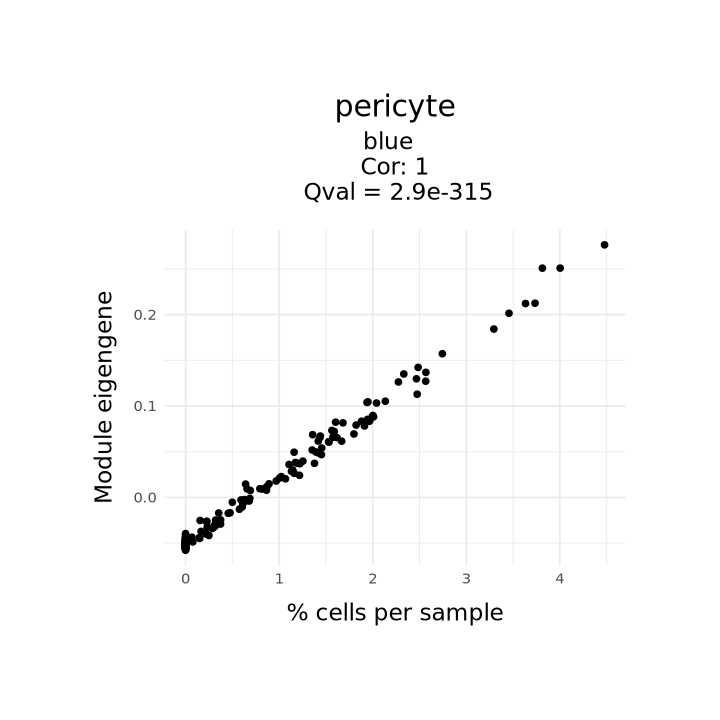

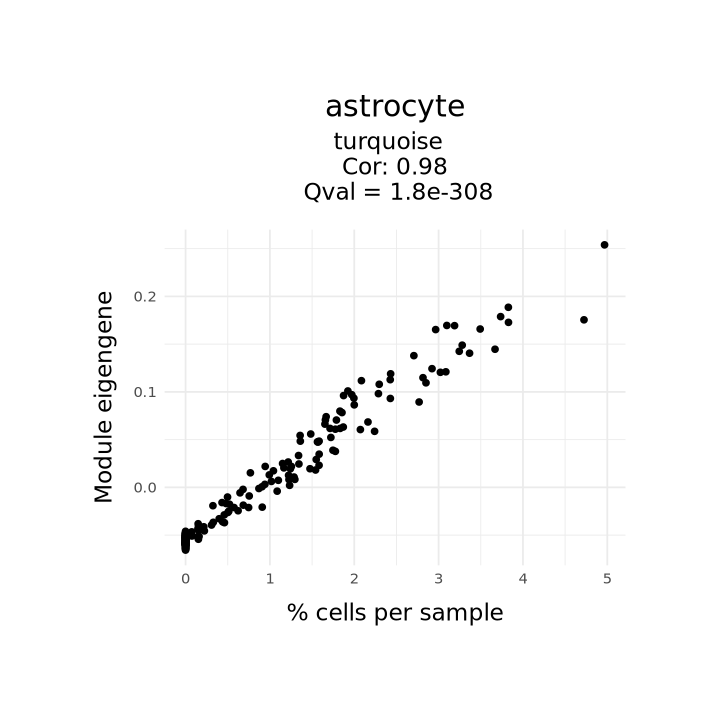

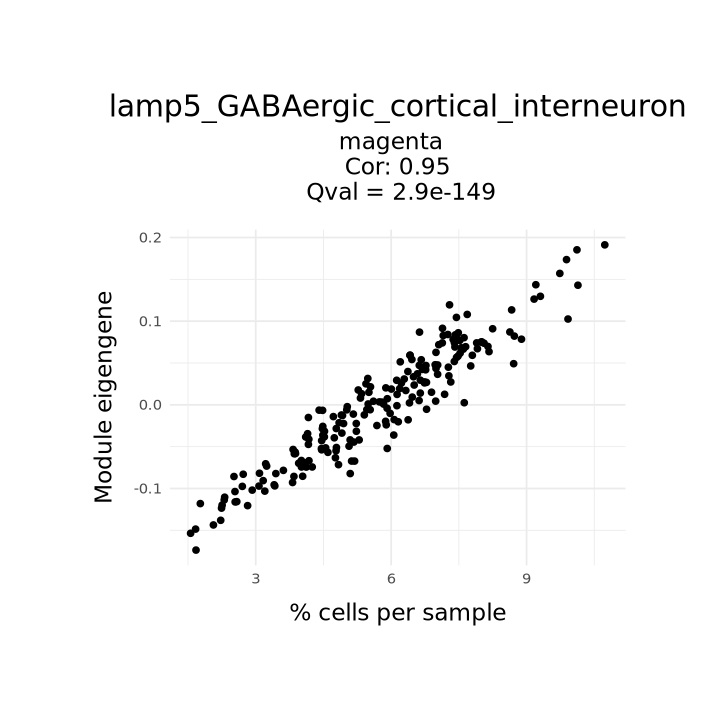

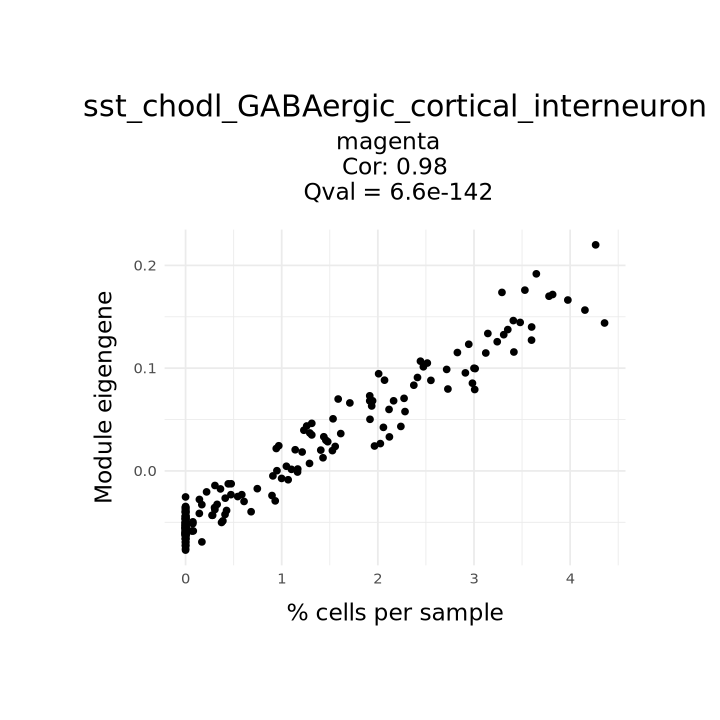

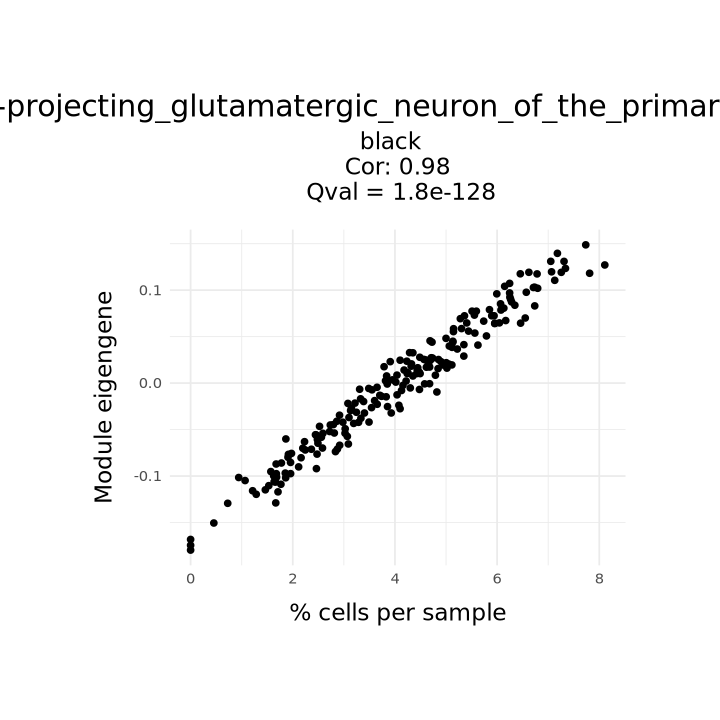

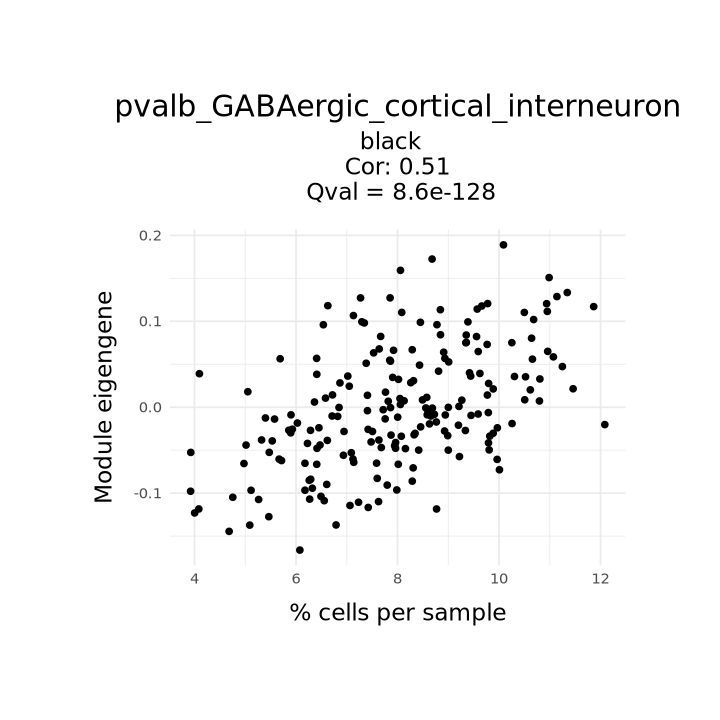

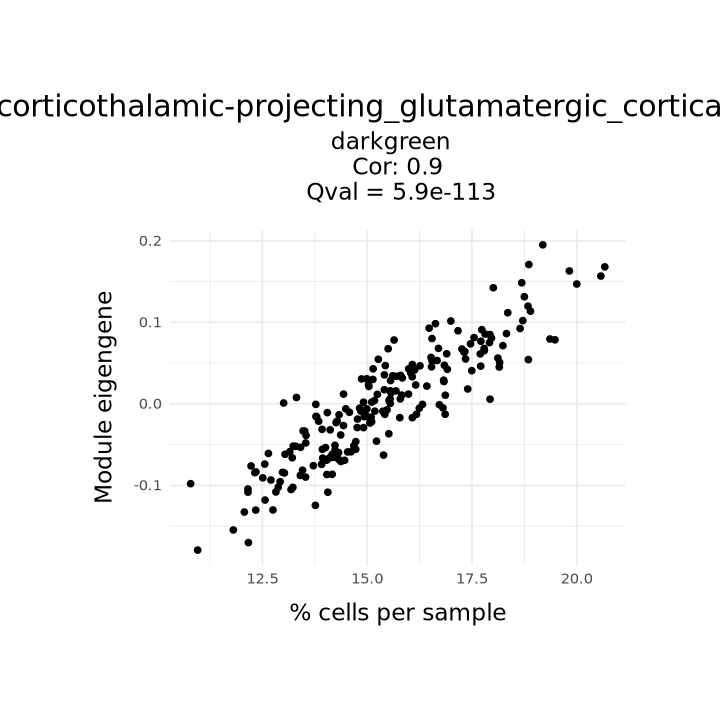

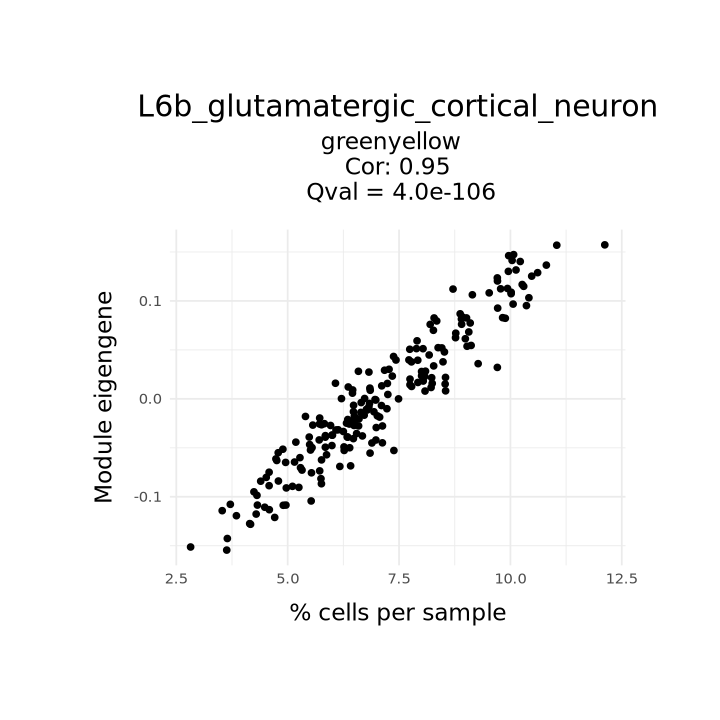

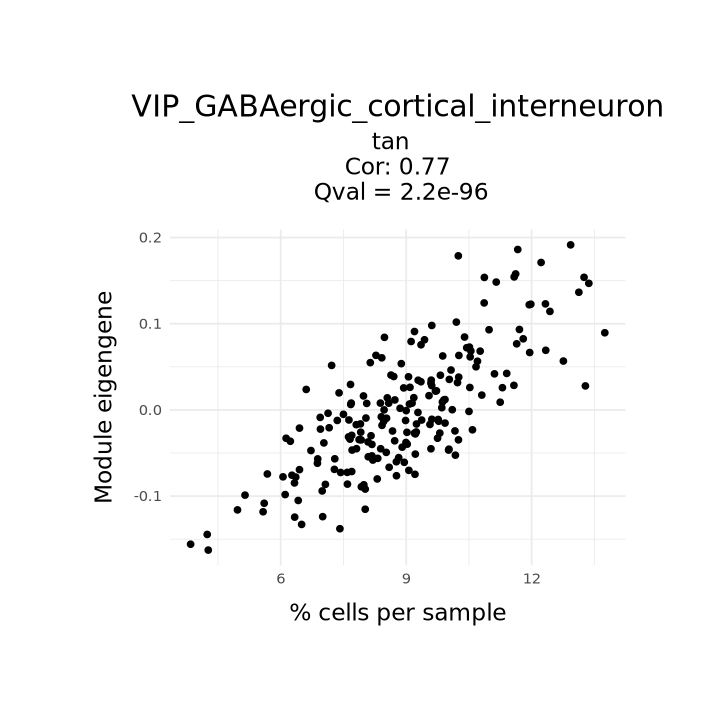

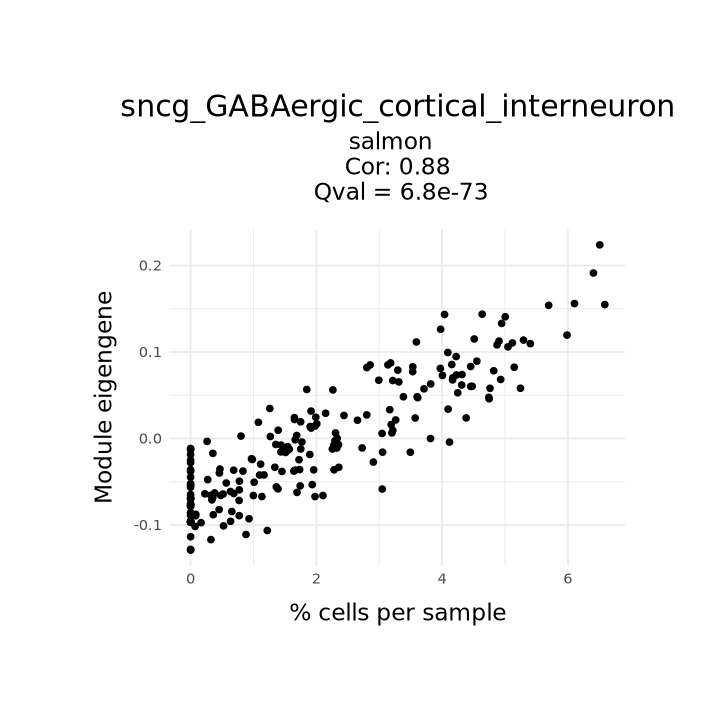

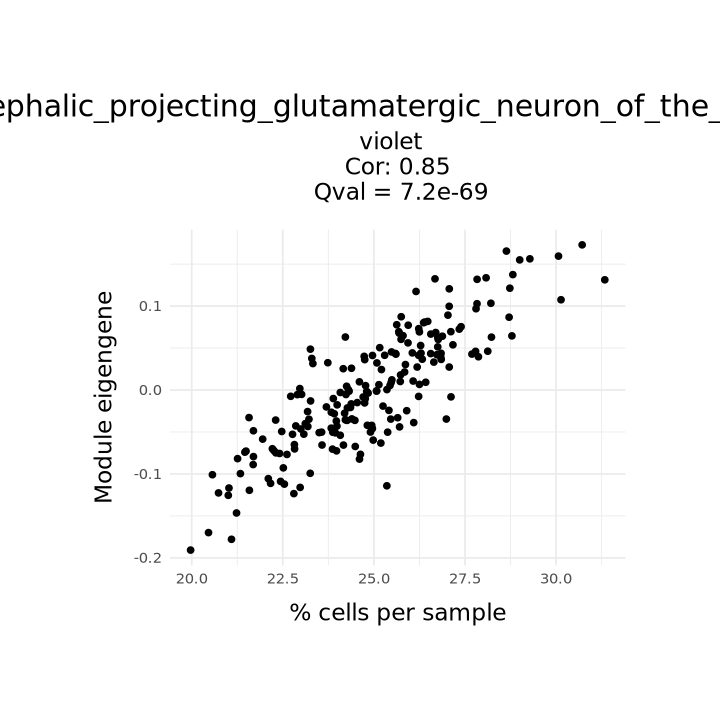

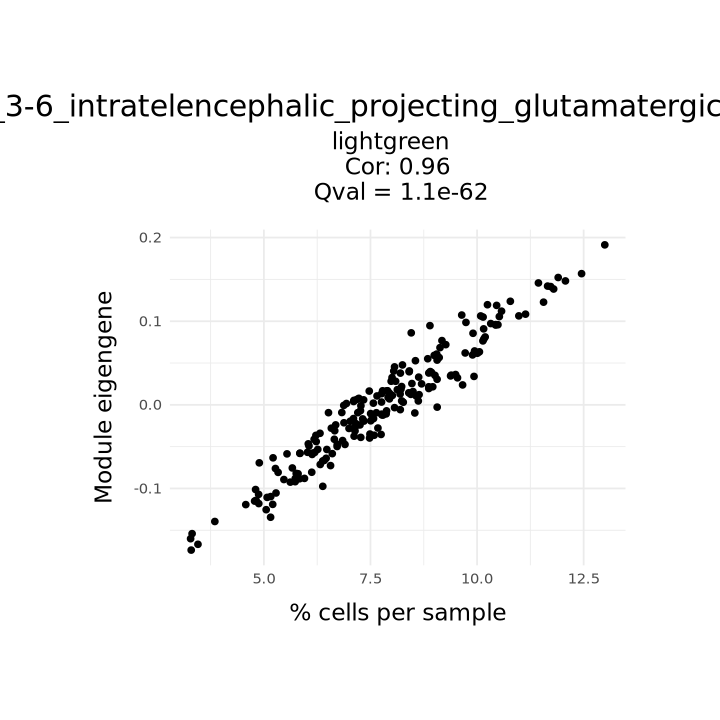

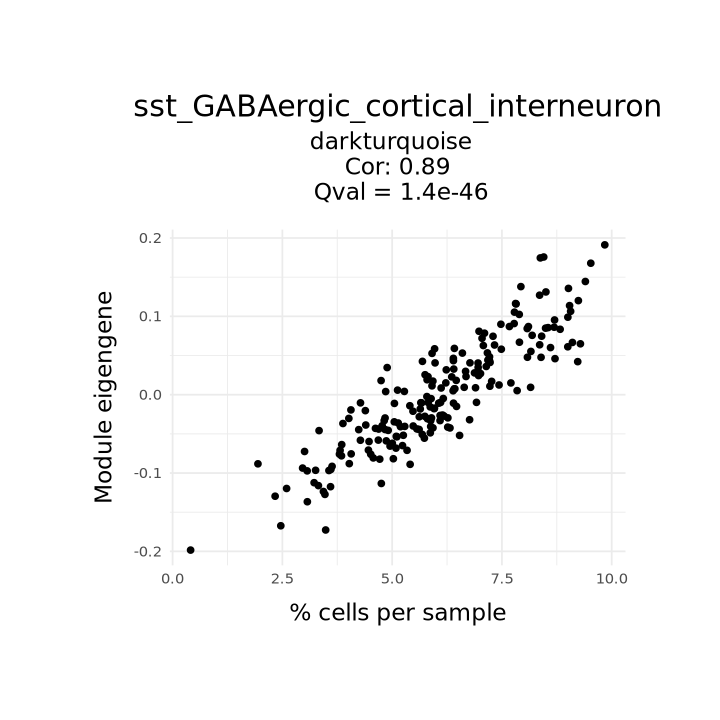

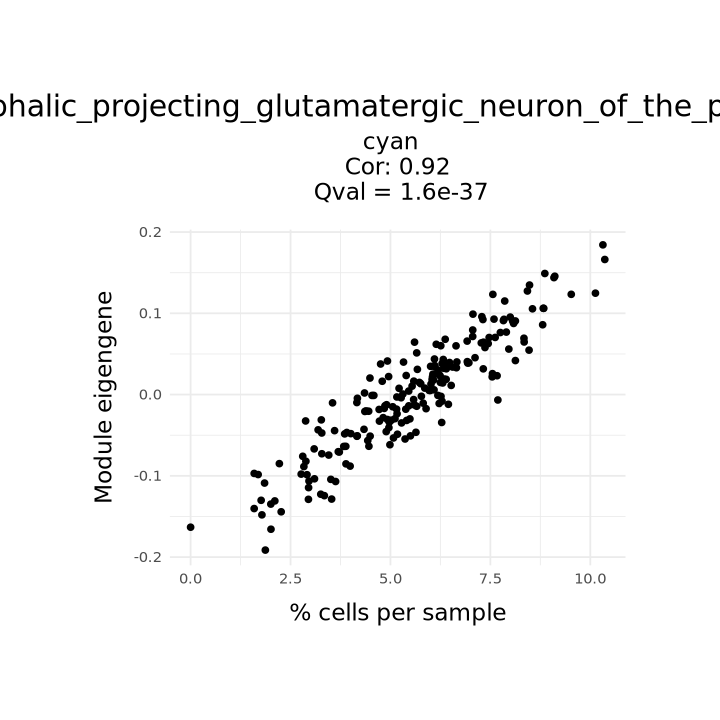

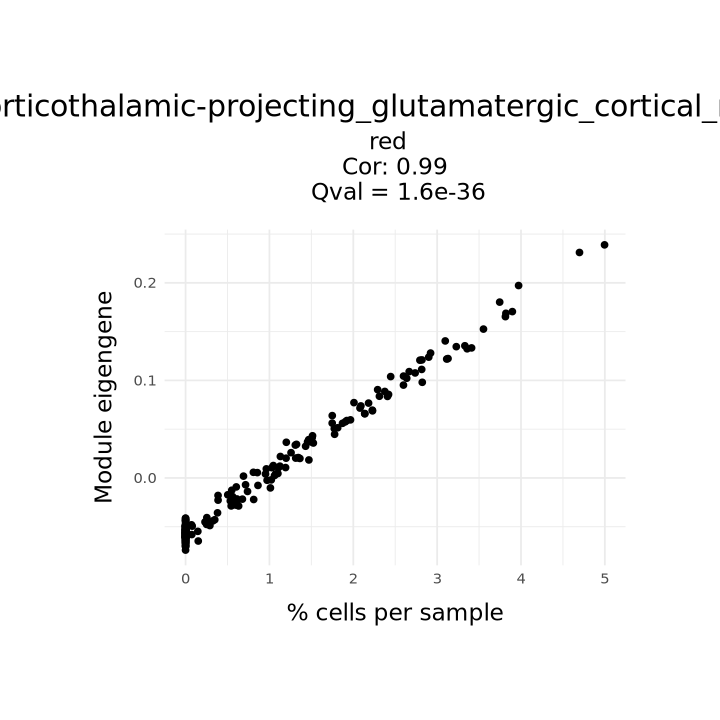

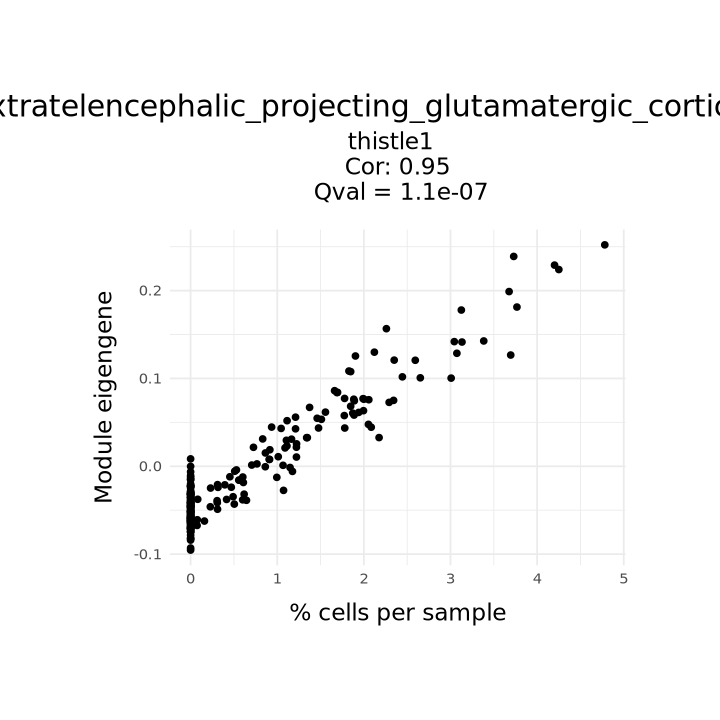

In [11]:
plot_ctype_abundance_vs_top_qval_ME(pseudobulk_legend, top_qval_mods_df)